# Intelligent Credit Risk & Loan Default Analytics
**End-to-End Data Analytics Notebook**

Dataset: `Financial Risk Modeling P.csv`

Sections: Data Loading → Cleaning → Feature Engineering → EDA → Clustering → ML Models → Insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              roc_curve, classification_report)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')
plt.style.use('dark_background')
print('Libraries loaded.')

Libraries loaded.


## 1. Data Loading & Overview

In [2]:
df = pd.read_csv(r'D:\New folder\Intelligent Credit Risk & Loan Default Analytics\Financial Risk Modeling P.csv')
print('Shape:', df.shape)
df.head()

Shape: (129063, 11)


,Customer_ID,Age,Employment_Type,Monthly_Income,Loan_Amount,Credit_Score,Existing_Loans,Missed_Payments,City,Application_Date,Loan_Default
0,100001,59,1,107404.19,359597.01,594,1,1,2,1454,0
1,100002,49,0,66686.14,919375.97,602,0,0,4,688,0
2,100003,35,3,24522.83,135992.51,793,1,1,3,72,1
3,100004,63,0,36904.59,183844.99,819,1,0,1,1382,0
4,100005,28,1,21982.99,134632.46,820,3,1,4,250,1


In [3]:
print('=== Dataset Info ===')
df.info()
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\nDuplicates:', df.duplicated().sum())

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 129063 entries, 0 to 129062
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Customer_ID       129063 non-null  int64  
 1   Age               129063 non-null  int64  
 2   Employment_Type   129063 non-null  int64  
 3   Monthly_Income    129063 non-null  float64
 4   Loan_Amount       129063 non-null  float64
 5   Credit_Score      129063 non-null  int64  
 6   Existing_Loans    129063 non-null  int64  
 7   Missed_Payments   129063 non-null  int64  
 8   City              129063 non-null  int64  
 9   Application_Date  129063 non-null  int64  
 10  Loan_Default      129063 non-null  int64  
dtypes: float64(2), int64(9)
memory usage: 10.8 MB

=== Missing Values ===
Customer_ID         0
Age                 0
Employment_Type     0
Monthly_Income      0
Loan_Amount         0
Credit_Score        0
Existing_Loans      0
Missed_Payments     0
City

In [4]:
df.describe().round(2)

,Customer_ID,Age,Employment_Type,Monthly_Income,Loan_Amount,Credit_Score,Existing_Loans,Missed_Payments,City,Application_Date,Loan_Default
count,129063.00,129063.00,129063.00,129063.00,129063.00,129063.00,129063.00,129063.0,129063.00,129063.00,129063.00
mean,164532.00,45.03,1.45,60234.27,542195.85,678.52,1.50,1.2,2.50,749.71,0.48
std,37257.42,14.11,0.97,24571.07,316366.43,87.62,1.22,1.1,1.71,432.69,0.50
min,100001.00,21.00,0.00,10000.00,30013.21,300.00,0.00,0.0,0.00,0.00,0.00
25%,132266.50,33.00,0.00,43096.41,296279.67,619.00,1.00,0.0,1.00,375.00,0.00
50%,164532.00,45.00,2.00,59977.74,485842.68,679.00,1.00,1.0,2.00,749.00,0.00
75%,196797.50,57.00,2.00,76945.54,735610.38,740.00,2.00,2.0,4.00,1125.00,1.00
max,229063.00,69.00,3.00,175877.59,2331659.72,850.00,9.00,9.0,5.00,1499.00,1.00


In [5]:
print('Target Distribution:')
print(df['Loan_Default'].value_counts())
print(f'Default Rate: {df["Loan_Default"].mean():.2%}')

Target Distribution:
Loan_Default
0    67269
1    61794
Name: count, dtype: int64
Default Rate: 47.88%


## 2. Data Cleaning

In [6]:
df.drop_duplicates(inplace=True)
df['Monthly_Income']  = df['Monthly_Income'].clip(lower=10000)
df['Credit_Score']    = df['Credit_Score'].clip(300, 850)
df['Existing_Loans']  = df['Existing_Loans'].clip(lower=0)
df['Missed_Payments'] = df['Missed_Payments'].clip(lower=0)
EMPLOYMENT_MAP = {0:'Self-Employed', 1:'Salaried', 2:'Business', 3:'Freelancer'}
df['Employment_Label'] = df['Employment_Type'].map(EMPLOYMENT_MAP)
print('Cleaned shape:', df.shape)

Cleaned shape: (129063, 12)


## 3. Feature Engineering

In [7]:
df['Monthly_Loan_Payment'] = df['Loan_Amount'] / 60
df['DTI_Ratio']            = df['Monthly_Loan_Payment'] / df['Monthly_Income']
df['Loan_to_Income']       = df['Loan_Amount'] / df['Monthly_Income']
df['Credit_Band'] = pd.cut(df['Credit_Score'],
    bins=[0,580,670,740,800,850],
    labels=['Poor','Fair','Good','Very Good','Exceptional'])
df['Risk_Score'] = (
    (df['Missed_Payments'] * 2) + df['Existing_Loans'] +
    (df['DTI_Ratio'] * 10) - (df['Credit_Score'] / 100)
)
df['Age_Group'] = pd.cut(df['Age'], bins=[18,30,40,50,60,70],
    labels=['18-30','31-40','41-50','51-60','61-70'])
print('Engineered features:')
df[['DTI_Ratio','Loan_to_Income','Credit_Band','Risk_Score','Age_Group']].head()

Engineered features:


,DTI_Ratio,Loan_to_Income,Credit_Band,Risk_Score,Age_Group
0,0.055801,3.348072,Fair,-2.381988,51-60
1,0.229777,13.786612,Fair,-3.722231,41-50
2,0.092426,5.545547,Very Good,-4.005742,31-40
3,0.083027,4.981629,Exceptional,-6.359728,61-70
4,0.102073,6.124393,Exceptional,-2.179268,18-30


## 4. Exploratory Data Analysis

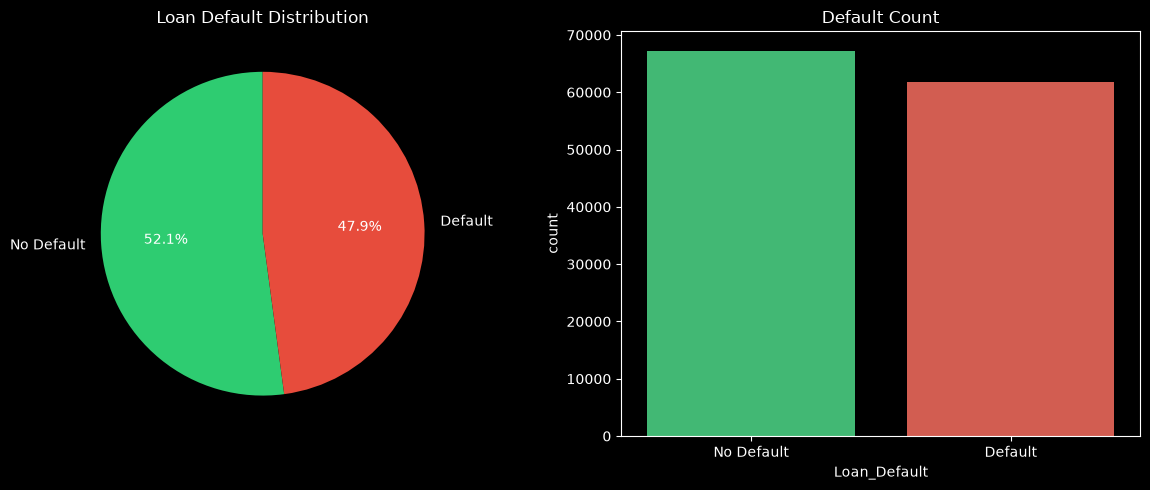

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
counts = df['Loan_Default'].value_counts()
axes[0].pie(counts, labels=['No Default','Default'], autopct='%1.1f%%',
            colors=['#2ecc71','#e74c3c'], startangle=90)
axes[0].set_title('Loan Default Distribution')
sns.countplot(x='Loan_Default', data=df, palette=['#2ecc71','#e74c3c'], ax=axes[1])
axes[1].set_title('Default Count')
axes[1].set_xticklabels(['No Default','Default'])
plt.tight_layout(); plt.show()

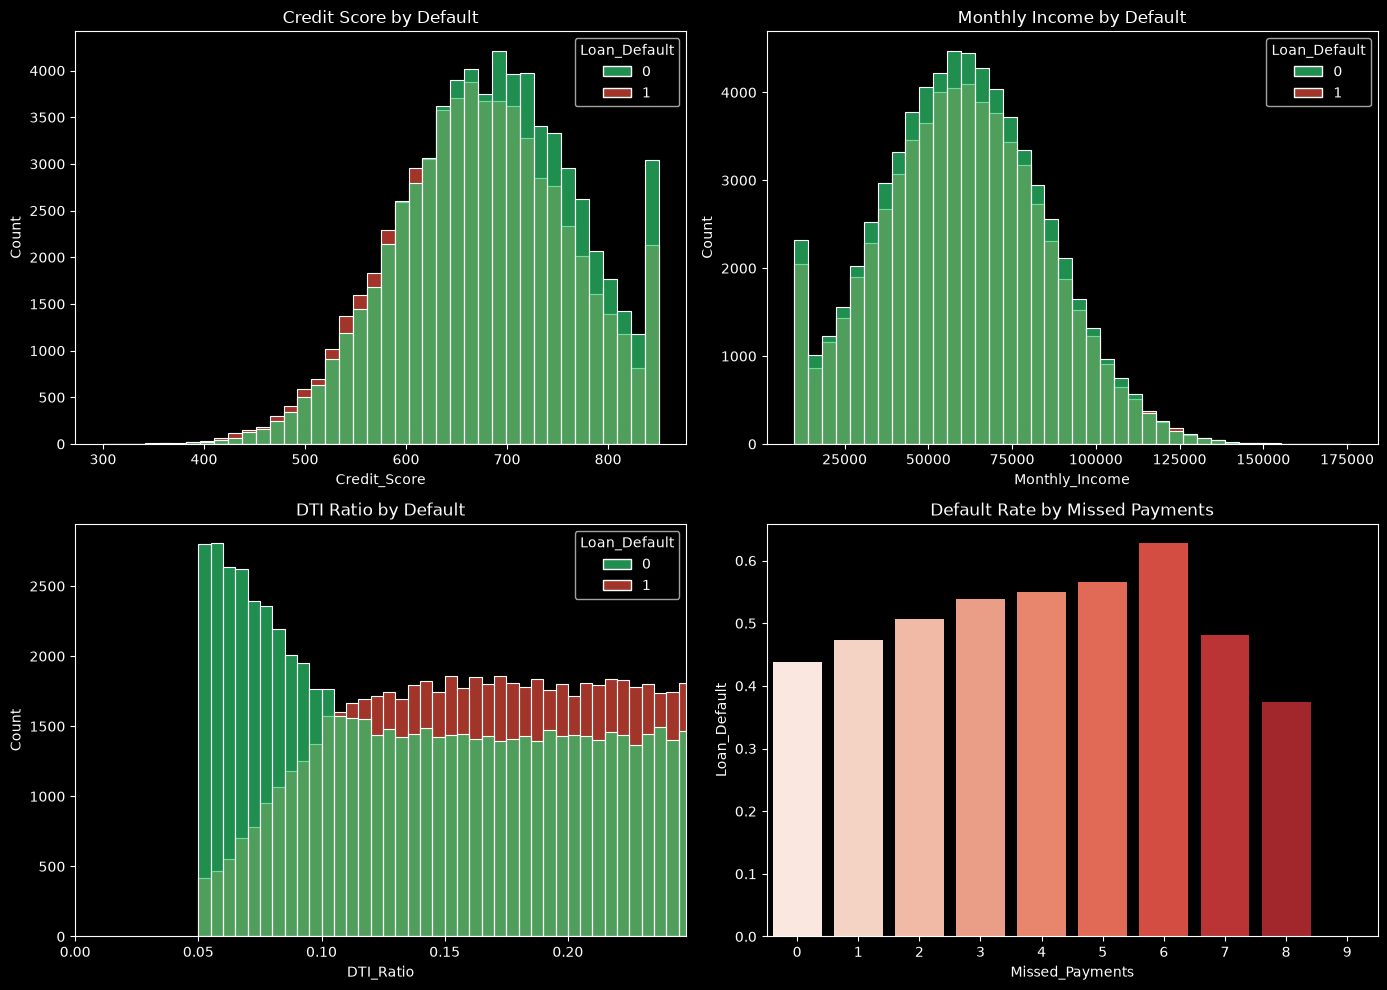

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(data=df, x='Credit_Score', hue='Loan_Default', bins=40,
             palette=['#2ecc71','#e74c3c'], ax=axes[0,0], alpha=0.7)
axes[0,0].set_title('Credit Score by Default')
sns.histplot(data=df, x='Monthly_Income', hue='Loan_Default', bins=40,
             palette=['#2ecc71','#e74c3c'], ax=axes[0,1], alpha=0.7)
axes[0,1].set_title('Monthly Income by Default')
sns.histplot(data=df, x='DTI_Ratio', hue='Loan_Default', bins=40,
             palette=['#2ecc71','#e74c3c'], ax=axes[1,0], alpha=0.7)
axes[1,0].set_title('DTI Ratio by Default')
axes[1,0].set_xlim(0, df['DTI_Ratio'].quantile(0.99))
dr = df.groupby('Missed_Payments')['Loan_Default'].mean().reset_index()
sns.barplot(x='Missed_Payments', y='Loan_Default', data=dr, palette='Reds', ax=axes[1,1])
axes[1,1].set_title('Default Rate by Missed Payments')
plt.tight_layout(); plt.show()

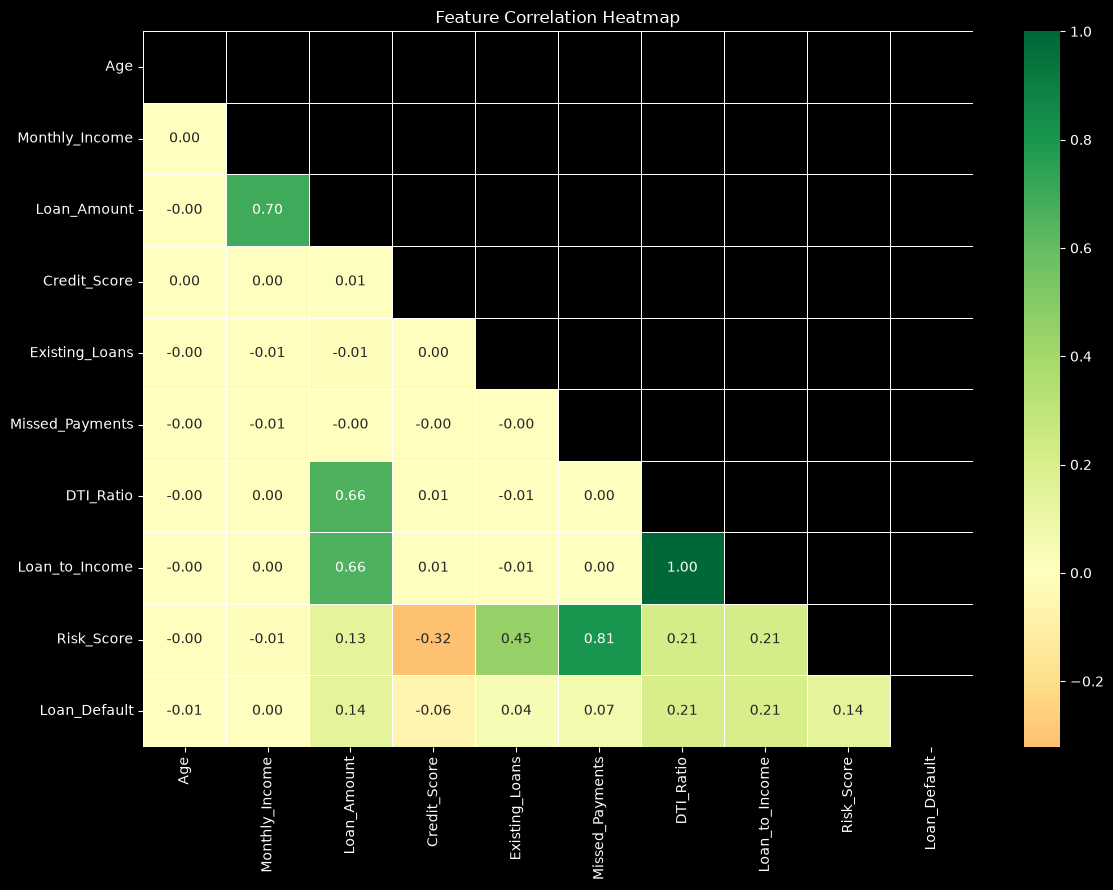

In [10]:
num_cols = ['Age','Monthly_Income','Loan_Amount','Credit_Score',
            'Existing_Loans','Missed_Payments','DTI_Ratio',
            'Loan_to_Income','Risk_Score','Loan_Default']
corr = df[num_cols].corr()
plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn', center=0, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout(); plt.show()

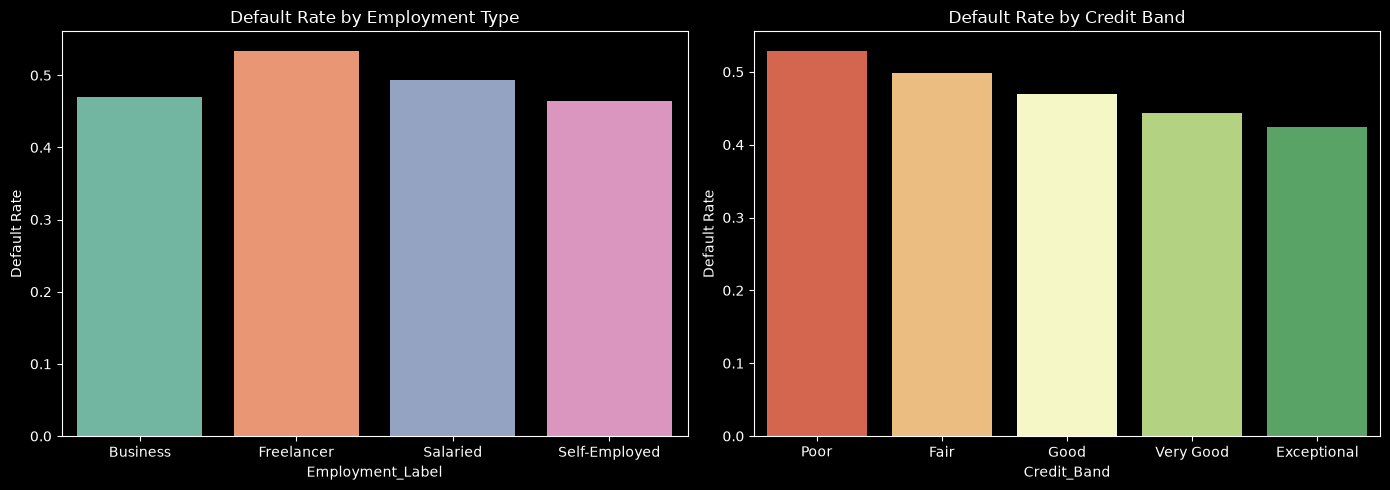

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
emp_dr = df.groupby('Employment_Label')['Loan_Default'].mean().reset_index()
sns.barplot(x='Employment_Label', y='Loan_Default', data=emp_dr, palette='Set2', ax=axes[0])
axes[0].set_title('Default Rate by Employment Type'); axes[0].set_ylabel('Default Rate')
band_dr = df.groupby('Credit_Band', observed=True)['Loan_Default'].mean().reset_index()
sns.barplot(x='Credit_Band', y='Loan_Default', data=band_dr, palette='RdYlGn', ax=axes[1])
axes[1].set_title('Default Rate by Credit Band'); axes[1].set_ylabel('Default Rate')
plt.tight_layout(); plt.show()

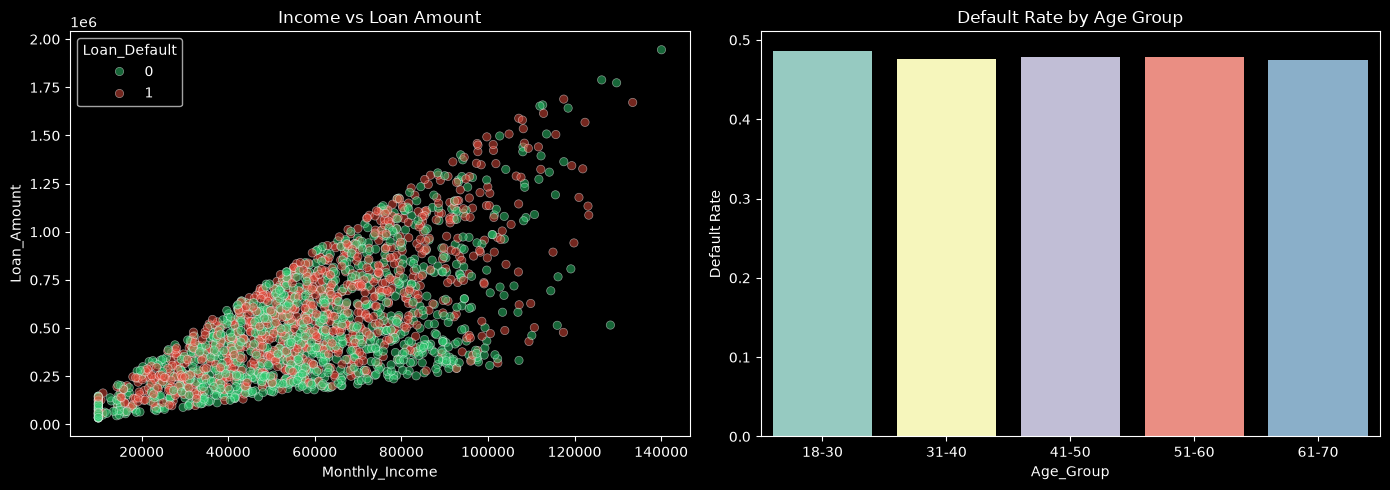

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df.sample(2000, random_state=42),
                x='Monthly_Income', y='Loan_Amount', hue='Loan_Default',
                palette=['#2ecc71','#e74c3c'], alpha=0.5, ax=axes[0])
axes[0].set_title('Income vs Loan Amount')
age_dr = df.groupby('Age_Group', observed=True)['Loan_Default'].mean().reset_index()
sns.barplot(x='Age_Group', y='Loan_Default', data=age_dr, palette='Set3', ax=axes[1])
axes[1].set_title('Default Rate by Age Group'); axes[1].set_ylabel('Default Rate')
plt.tight_layout(); plt.show()

## 5. Customer Segmentation (K-Means Clustering)

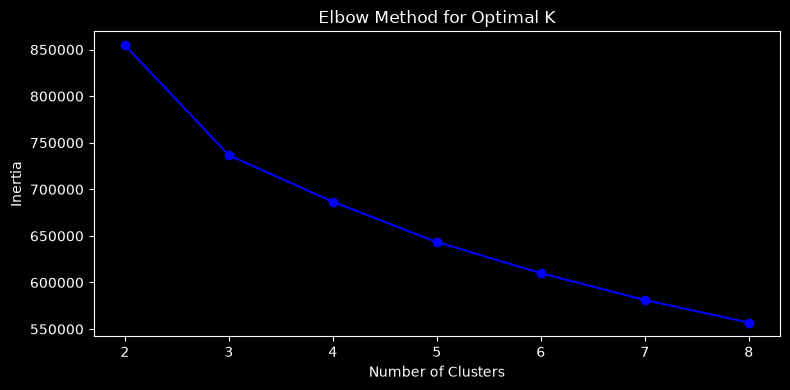

In [13]:
cluster_features = ['Age','Monthly_Income','Loan_Amount','Credit_Score',
                    'DTI_Ratio','Missed_Payments','Existing_Loans','Risk_Score']
scaler_c = StandardScaler()
X_scaled = scaler_c.fit_transform(df[cluster_features])

inertias = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    inertias.append(km.fit(X_scaled).inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(2, 9), inertias, 'bo-')
plt.xlabel('Number of Clusters'); plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.tight_layout(); plt.show()

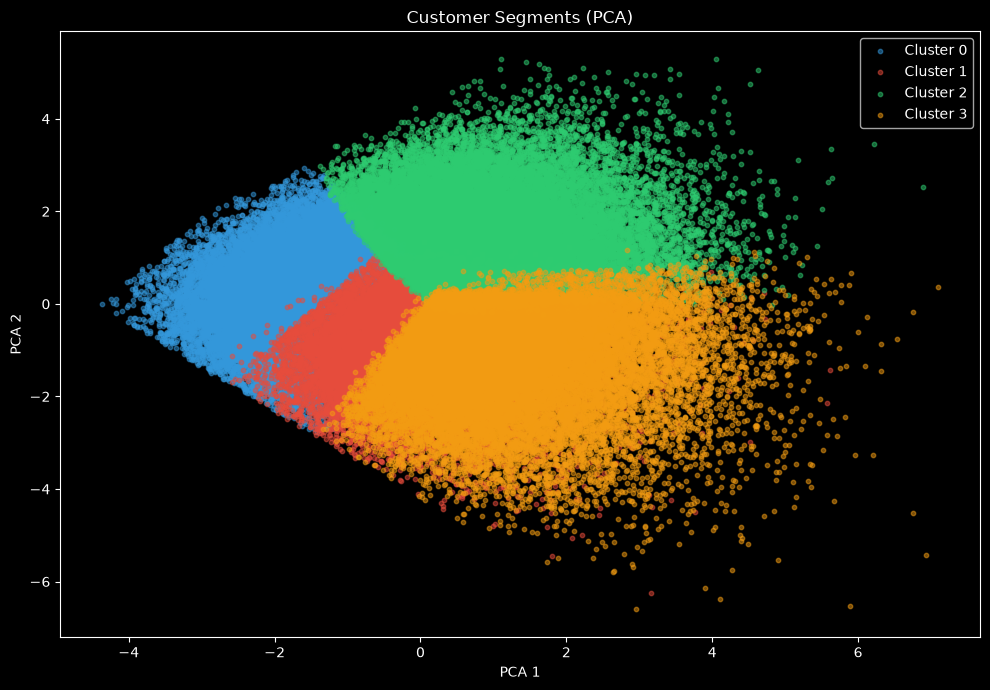

In [14]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
colors = ['#3498db','#e74c3c','#2ecc71','#f39c12']
for c in range(4):
    mask = df['Cluster'].values == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=f'Cluster {c}', alpha=0.5, s=10, color=colors[c])
plt.title('Customer Segments (PCA)'); plt.xlabel('PCA 1'); plt.ylabel('PCA 2')
plt.legend(); plt.tight_layout(); plt.show()

In [15]:
profile_cols = ['Age','Monthly_Income','Loan_Amount','Credit_Score',
                'DTI_Ratio','Missed_Payments','Existing_Loans','Loan_Default']
cluster_profile = df.groupby('Cluster')[profile_cols].mean().round(2)
cluster_profile['Count'] = df.groupby('Cluster').size()
cluster_profile['Default_Rate_%'] = (cluster_profile['Loan_Default'] * 100).round(1)
print('Cluster Profiles:')
cluster_profile

Cluster Profiles:


,Age,Monthly_Income,Loan_Amount,Credit_Score,DTI_Ratio,Missed_Payments,Existing_Loans,Loan_Default,Count,Default_Rate_%
Cluster,,,,,,,,,,
0,45.05,52381.45,341531.87,698.56,0.12,0.69,0.88,0.36,45908,36.0
1,45.21,51035.76,394949.66,656.04,0.14,1.00,3.03,0.52,24429,52.0
2,45.06,79576.62,929897.37,684.08,0.20,0.86,1.28,0.56,33735,56.0
3,44.78,57541.47,531393.91,656.16,0.16,2.81,1.45,0.55,24991,55.0


## 6. ML Model Training & Evaluation

In [16]:
features = ['Age','Employment_Type','Monthly_Income','Loan_Amount',
            'Credit_Score','Existing_Loans','Missed_Payments',
            'DTI_Ratio','Loan_to_Income','Risk_Score']
X = df[features]
y = df['Loan_Default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_s, y_train)
print(f'Train after SMOTE: {X_train_res.shape[0]} | Test: {X_test_s.shape[0]}')

Train after SMOTE: 107630 | Test: 25813


In [17]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Decision Tree':       DecisionTreeClassifier(max_depth=8, random_state=42, class_weight='balanced'),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42,
                                                   class_weight='balanced', n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, max_depth=5,
                                                       learning_rate=0.05, random_state=42)
}

results = {}
metrics_list = []

for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test_s)
    y_prob = model.predict_proba(X_test_s)[:, 1]
    m = {'Model': name,
         'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
         'Precision': round(precision_score(y_test, y_pred), 4),
         'Recall':    round(recall_score(y_test, y_pred), 4),
         'F1':        round(f1_score(y_test, y_pred), 4),
         'ROC_AUC':   round(roc_auc_score(y_test, y_prob), 4)}
    results[name] = (model, y_pred, y_prob)
    metrics_list.append(m)
    print(f'  {m}')

pd.DataFrame(metrics_list).set_index('Model')

Training Logistic Regression...
  {'Model': 'Logistic Regression', 'Accuracy': 0.577, 'Precision': 0.5562, 'Recall': 0.5767, 'F1': 0.5663, 'ROC_AUC': 0.6274}
Training Decision Tree...
  {'Model': 'Decision Tree', 'Accuracy': 0.6038, 'Precision': 0.5529, 'Recall': 0.902, 'F1': 0.6855, 'ROC_AUC': 0.6233}
Training Random Forest...
  {'Model': 'Random Forest', 'Accuracy': 0.6086, 'Precision': 0.5553, 'Recall': 0.917, 'F1': 0.6917, 'ROC_AUC': 0.6341}
Training Gradient Boosting...
  {'Model': 'Gradient Boosting', 'Accuracy': 0.6084, 'Precision': 0.5554, 'Recall': 0.9125, 'F1': 0.6905, 'ROC_AUC': 0.6353}


,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
Logistic Regression,0.5770,0.5562,0.5767,0.5663,0.6274
Decision Tree,0.6038,0.5529,0.9020,0.6855,0.6233
Random Forest,0.6086,0.5553,0.9170,0.6917,0.6341
Gradient Boosting,0.6084,0.5554,0.9125,0.6905,0.6353


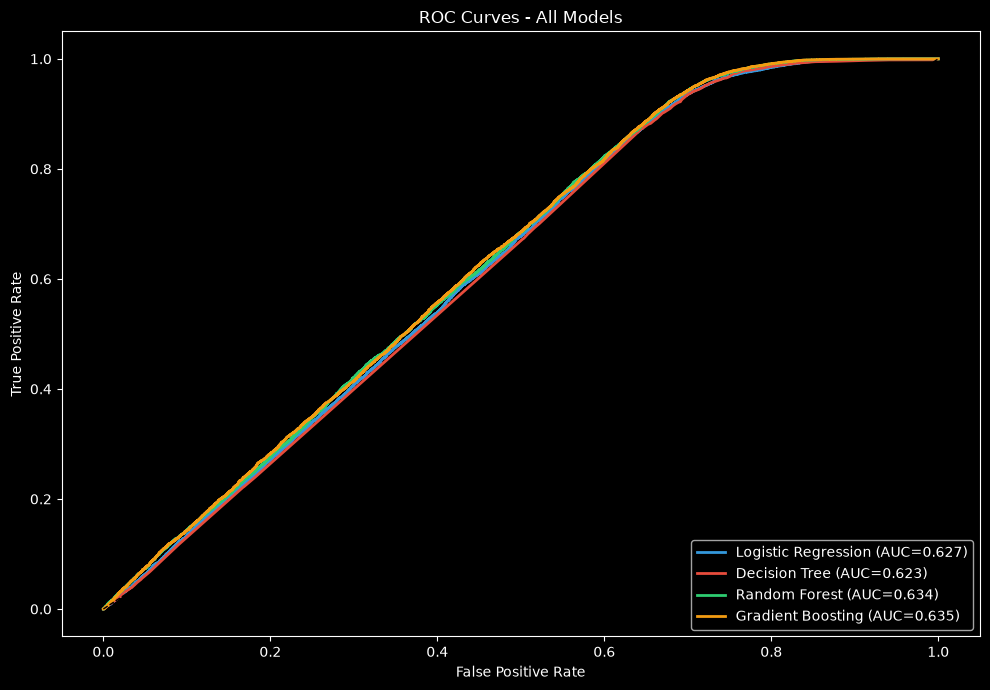

In [18]:
plt.figure(figsize=(10, 7))
colors = ['#3498db','#e74c3c','#2ecc71','#f39c12']
for (name, (_, _, y_prob)), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend(loc='lower right')
plt.tight_layout(); plt.show()

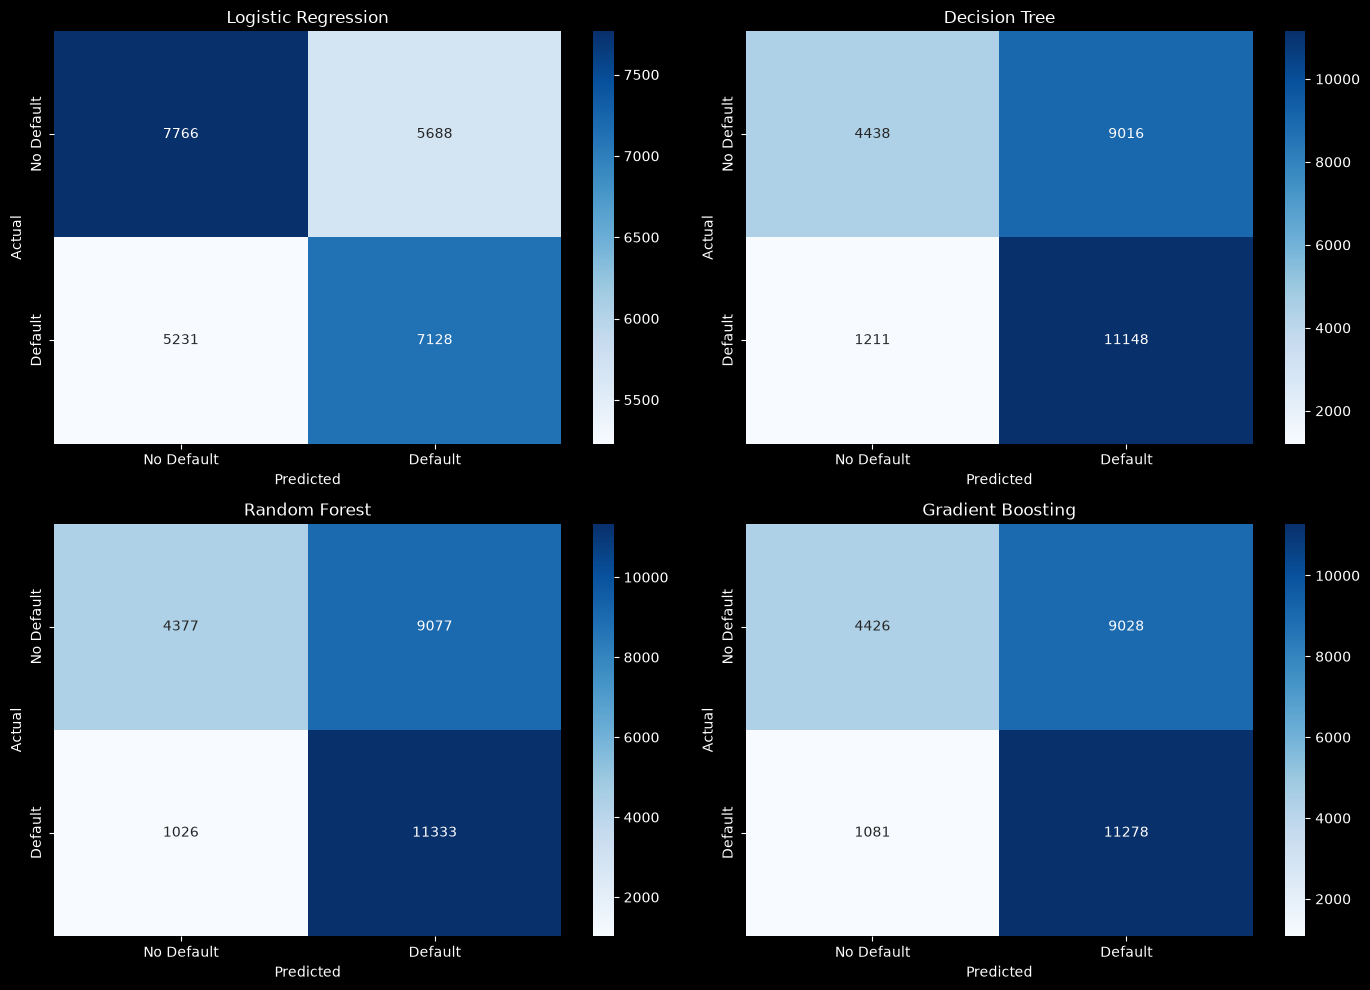

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, (name, (_, y_pred, _)) in enumerate(results.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No Default','Default'],
                yticklabels=['No Default','Default'])
    axes[i].set_title(name)
    axes[i].set_ylabel('Actual'); axes[i].set_xlabel('Predicted')
plt.tight_layout(); plt.show()

Best Model: Gradient Boosting


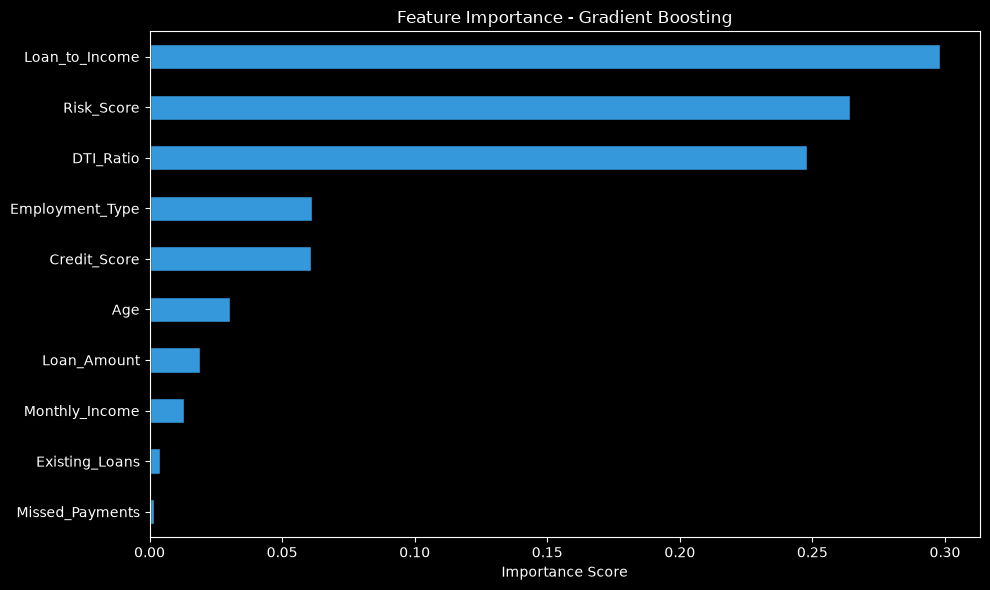


Classification Report (Gradient Boosting):
              precision    recall  f1-score   support

  No Default       0.80      0.33      0.47     13454
     Default       0.56      0.91      0.69     12359

    accuracy                           0.61     25813
   macro avg       0.68      0.62      0.58     25813
weighted avg       0.68      0.61      0.57     25813



In [20]:
best_name = max(metrics_list, key=lambda x: x['ROC_AUC'])['Model']
best_model = results[best_name][0]
print(f'Best Model: {best_name}')

importances = (best_model.feature_importances_
               if hasattr(best_model, 'feature_importances_')
               else np.abs(best_model.coef_[0]))
fi = pd.Series(importances, index=features).sort_values(ascending=True)
plt.figure(figsize=(10, 6))
fi.plot(kind='barh', color='#3498db', edgecolor='black')
plt.title(f'Feature Importance - {best_name}')
plt.xlabel('Importance Score')
plt.tight_layout(); plt.show()

print(f'\nClassification Report ({best_name}):')
print(classification_report(y_test, results[best_name][1],
      target_names=['No Default','Default']))

## 7. Business Insights & Recommendations

In [21]:
default_rate = df['Loan_Default'].mean()
high_dti_dr  = df[df['DTI_Ratio'] > 0.5]['Loan_Default'].mean()
low_cs_dr    = df[df['Credit_Score'] < 580]['Loan_Default'].mean()
missed1_dr   = df[df['Missed_Payments'] >= 1]['Loan_Default'].mean()

print('=' * 60)
print('  KEY METRICS')
print('=' * 60)
print(f'  Overall Default Rate       : {default_rate:.1%}')
print(f'  Default Rate (DTI > 0.5)   : {high_dti_dr:.1%}')
print(f'  Default Rate (Score < 580) : {low_cs_dr:.1%}')
print(f'  Default Rate (>=1 Missed)  : {missed1_dr:.1%}')
print()
print('=' * 60)
print('  BUSINESS RECOMMENDATIONS')
print('=' * 60)
print('''
1. CREDIT SCORE THRESHOLD
   Set minimum score of 580 for standard approval.
   Offer secured products below 580.

2. DTI RATIO CAP
   Reject or reduce loan for DTI > 0.43.
   Offer debt consolidation for high-DTI customers.

3. MISSED PAYMENT EARLY WARNING
   Trigger outreach within 30 days of first missed payment.
   Offer restructuring before escalation.

4. LOAN-TO-INCOME LIMIT
   Cap loan at 10x monthly income for new customers.
   Graduated limits based on credit history.

5. SEGMENT-BASED PRICING
   Use 4 customer clusters for risk-based interest rates.
   High-risk segments require collateral or co-signers.

6. MODEL DEPLOYMENT
   Use probability threshold 0.40 (not 0.50) to maximize recall.
   Manual review for 40-60% probability borderline cases.
   Retrain model quarterly with fresh data.

7. RESPONSIBLE AI
   Monitor for demographic bias across age/employment groups.
   Provide explainability (SHAP) for rejected applications.
   Ensure GDPR/data privacy compliance in production.
''')

  KEY METRICS
  Overall Default Rate       : 47.9%
  Default Rate (DTI > 0.5)   : nan%
  Default Rate (Score < 580) : 53.0%
  Default Rate (>=1 Missed)  : 49.6%

  BUSINESS RECOMMENDATIONS

1. CREDIT SCORE THRESHOLD
   Set minimum score of 580 for standard approval.
   Offer secured products below 580.

2. DTI RATIO CAP
   Reject or reduce loan for DTI > 0.43.
   Offer debt consolidation for high-DTI customers.

3. MISSED PAYMENT EARLY WARNING
   Trigger outreach within 30 days of first missed payment.
   Offer restructuring before escalation.

4. LOAN-TO-INCOME LIMIT
   Cap loan at 10x monthly income for new customers.
   Graduated limits based on credit history.

5. SEGMENT-BASED PRICING
   Use 4 customer clusters for risk-based interest rates.
   High-risk segments require collateral or co-signers.

6. MODEL DEPLOYMENT
   Use probability threshold 0.40 (not 0.50) to maximize recall.
   Manual review for 40-60% probability borderline cases.
   Retrain model quarterly with fresh data.